# UNIT IV

## WORDVEC2

In [15]:
import nltk
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [16]:
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings

warnings.filterwarnings(action='ignore')

In [17]:
import os
os.getcwd()


'C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP'

In [18]:
import zipfile

with zipfile.ZipFile("C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\Gutenburg.zip", 'r') as zip_ref:
    file_name = zip_ref.namelist()[0]
    with zip_ref.open(file_name) as file:
        content = file.read().decode('utf-8', errors='ignore')
        cleaned_text = content.replace("\n", " ")
        print("File loaded")

File loaded


In [19]:
data = []

for i in sent_tokenize(cleaned_text):
    temp = []

    # tokenize the sentence into words
    for j in word_tokenize(i):
        temp.append(j.lower())

    data.append(temp)

In [20]:
model1 = gensim.models.Word2Vec(data, min_count=1,
                                vector_size=100, window=5)

In [21]:
model2 = gensim.models.Word2Vec(data, min_count=1, vector_size=100,
                                window=5, sg=1)

In [22]:
print("Cosine similarity between 'alice' " +
      "and 'wonderland' - CBOW : ",
      model1.wv.similarity('alice', 'wonderland'))

print("Cosine similarity between 'alice' " +
      "and 'machines' - CBOW : ",
      model1.wv.similarity('alice', 'machines'))

Cosine similarity between 'alice' and 'wonderland' - CBOW :  0.9921529
Cosine similarity between 'alice' and 'machines' - CBOW :  0.9420085


## GLOVE

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [24]:
texts = ['text', 'the', 'leader', 'prime', 'natural', 'language']

In [25]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

print("Number of unique words in dictionary =", len(tokenizer.word_index))
print("Dictionary is =", tokenizer.word_index)

Number of unique words in dictionary = 6
Dictionary is = {'text': 1, 'the': 2, 'leader': 3, 'prime': 4, 'natural': 5, 'language': 6}


In [26]:
def embedding_for_vocab(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1  # +1 for padding token (index 0)
    embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim))

    with open(filepath, encoding="utf8") as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim]

    return embedding_matrix_vocab

In [27]:
!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -q glove.6B.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [58]:
embedding_dim = 50 # match this with glove file
glove_path = 'C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\glove.6B\glove.6B.50d.txt'

embedding_matrix_vocab = embedding_for_vocab(glove_path, tokenizer.word_index, embedding_dim)

In [59]:
first_word_index = 1  # Tokenizer indexes start from 1
print("Dense vector for word with index 1 =>", embedding_matrix_vocab[first_word_index])

Dense vector for word with index 1 => [ 0.32615     0.36686    -0.0074905  -0.37553     0.66715002  0.21646
 -0.19801    -1.10010004 -0.42221001  0.10574    -0.31292     0.50953001
  0.55774999  0.12019     0.31441    -0.25042999 -1.06369996 -1.32130003
  0.87797999 -0.24627     0.27379    -0.51091999  0.49324     0.52243
  1.16359997 -0.75322998 -0.48052999 -0.11259    -0.54595    -0.83920997
  2.98250008 -1.19159997 -0.51958001 -0.39365    -0.1419     -0.026977
  0.66295999  0.16574    -1.1681      0.14443     1.63049996 -0.17216
 -0.17436001 -0.01049    -0.17794     0.93076003  1.0381      0.94265997
 -0.14805    -0.61109   ]


## TOPIC MODELING (LDA)

In [8]:
!pip install --upgrade gensim pyLDAvis spacy pandas scikit-learn
import spacy.cli
spacy.cli.download("en_core_web_md")

import pandas as pd
import string
import spacy
import nltk
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from nltk.corpus import stopwords
import en_core_web_md
nltk.download('wordnet')
nltk.download('stopwords')

Defaulting to user installation because normal site-packages is not writeable
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [60]:
yelp_review = pd.read_csv('C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\mock_yelp.csv')
print("Number of reviews:", len(yelp_review))
print("Unique businesses:", len(yelp_review.groupby('business_id')))
print("Unique users:", len(yelp_review.groupby('user_id')))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\\mock_yelp.csv'

In [36]:
def clean_text(text):
    delete_dict = {sp_char: '' for sp_char in string.punctuation}
    delete_dict[' '] = ' '
    table = str.maketrans(delete_dict)
    text1 = text.translate(table)
    textArr = text1.split()
    text2 = ' '.join([w for w in textArr if not w.isdigit() and len(w) > 3])
    return text2.lower()


yelp_review['text'] = yelp_review['text'].apply(clean_text)
yelp_review['Num_words_text'] = yelp_review['text'].apply(
    lambda x: len(str(x).split()))

KeyError: 'text'

In [30]:
stop_words = stopwords.words('english')


def remove_stopwords(text):
    textArr = text.split(' ')
    rem_text = " ".join([i for i in textArr if i not in stop_words])
    return rem_text


yelp_review['text'] = yelp_review['text'].apply(remove_stopwords)

KeyError: 'text'

In [31]:
nlp = en_core_web_md.load(disable=['parser', 'ner'])


def lemmatization(texts, allowed_postags=['NOUN', 'ADJ']):
    output = []
    for sent in texts:
        doc = nlp(sent)
        output.append(
            [token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return output


text_list = yelp_review['text'].tolist()
tokenized_reviews = lemmatization(text_list)

KeyError: 'text'

In [37]:
dictionary = corpora.Dictionary(tokenized_reviews)
if len(dictionary) > 0:
    doc_term_matrix = [dictionary.doc2bow(rev) for rev in tokenized_reviews]
else:
    doc_term_matrix = []

NameError: name 'tokenized_reviews' is not defined

In [38]:
if doc_term_matrix:
    LDA = gensim.models.ldamodel.LdaModel
    lda_model = LDA(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=10,
        random_state=100,
        chunksize=1000,
        passes=50,
        iterations=100
    )
    print(lda_model.print_topics())
else:
    print("Document term matrix is empty, cannot build LDA model.")

NameError: name 'doc_term_matrix' is not defined

In [39]:
total_docs = len(doc_term_matrix)
if total_docs > 0:
    print('\nPerplexity:', lda_model.log_perplexity(
        doc_term_matrix, total_docs=total_docs))
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=tokenized_reviews,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_lda = coherence_model_lda.get_coherence()
    print('Coherence:', coherence_lda)
else:
    print("No documents to evaluate coherence or perplexity.")

NameError: name 'doc_term_matrix' is not defined

In [40]:
if total_docs > 0:
    pyLDAvis.enable_notebook()
    vis_data = gensimvis.prepare(lda_model, doc_term_matrix, dictionary)
    vis_data
    pyLDAvis.save_html(vis_data, 'lda_visualization.html')
else:
    print("No documents for visualization.")

NameError: name 'total_docs' is not defined

## SEUENCE2 SEQUENCE MODELS

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [22]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden

In [23]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden

In [24]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=10, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs = []

        hidden = self.encoder(src)

        input = torch.zeros(batch_size, dtype=torch.long).to(self.device)

        for t in range(max_len):
            output, hidden = self.decoder(input, hidden)
            top1 = output.argmax(1)
            outputs.append(top1.unsqueeze(0))

            if trg is not None and t < trg.shape[0] and torch.rand(1).item() < teacher_forcing_ratio:
                input = trg[t]
            else:
                input = top1

        outputs = torch.cat(outputs, dim=0)
        return outputs

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = 10
EMB_DIM = 8
HID_DIM = 16
SEQ_LEN = 5
BATCH_SIZE = 2

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

src = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)
trg = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)

outputs = model(src, trg, max_len=SEQ_LEN, teacher_forcing_ratio=0.7)

print("Source sequence (input tokens):")
print(src.T)
print("\nTarget sequence (true tokens):")
print(trg.T)
print("\nPredicted sequence (model output tokens):")
print(outputs.T)

Source sequence (input tokens):
tensor([[1, 2, 4, 6, 4],
        [5, 5, 9, 5, 5]])

Target sequence (true tokens):
tensor([[2, 4, 4, 4, 2],
        [5, 8, 4, 3, 6]])

Predicted sequence (model output tokens):
tensor([[9, 9, 9, 9, 9],
        [9, 9, 9, 9, 9]])


## HMM

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm

In [43]:
states = ["Sunny", "Rainy"]

transition_matrix = np.array([
    [0.8, 0.2],  
    [0.4, 0.6]  
])

print("\nTransition Matrix:")
print(transition_matrix)


Transition Matrix:
[[0.8 0.2]
 [0.4 0.6]]


In [44]:
def simulate_markov_chain(start_state, n_steps=20):
    current_state = states.index(start_state)
    sequence = [start_state]
    for _ in range(n_steps):
        current_state = np.random.choice([0, 1], p=transition_matrix[current_state])
        sequence.append(states[current_state])
    return sequence

mc_sequence = simulate_markov_chain("Sunny", 15)
print("\nGenerated Markov Chain Sequence:")
print(mc_sequence)


Generated Markov Chain Sequence:
['Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy']


In [45]:
hidden_states = ["Hot", "Cold"]
observations = ["IceCream", "Coffee"]

model = hmm.MultinomialHMM(n_components=2, n_iter=50)
model.transmat_ = np.array([
    [0.7, 0.3],  
    [0.4, 0.6]    
])
model.emissionprob_ = np.array([
    [0.8, 0.2],  
    [0.3, 0.7]   
])
model.startprob_ = np.array([0.6, 0.4])

print("\nTransition Matrix (Hidden States):")
print(model.transmat_)
print("\nEmission Matrix:")
print(model.emissionprob_)

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Transition Matrix (Hidden States):
[[0.7 0.3]
 [0.4 0.6]]

Emission Matrix:
[[0.8 0.2]
 [0.3 0.7]]


In [46]:
model.n_trials = 1
obs_seq, hidden_seq = model.sample(15)

obs_seq = obs_seq.flatten()
hidden_seq = hidden_seq.flatten()

decoded_obs = [observations[i] for i in obs_seq]
decoded_hidden = [hidden_states[i] for i in hidden_seq]

print("\nGenerated Observations from HMM:")
print(decoded_obs)
print("\nActual Hidden States from HMM:")
print(decoded_hidden)


Generated Observations from HMM:
['Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee']

Actual Hidden States from HMM:
['Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold', 'Cold']


In [47]:
n_observations = len(observations)
X_decoded = np.zeros((len(obs_seq), n_observations))
X_decoded[np.arange(len(obs_seq)), obs_seq] = 1

logprob, predicted_states = model.decode(X_decoded, algorithm="viterbi")
decoded_predicted = [hidden_states[i] for i in predicted_states]

print("\nPredicted Hidden States (Viterbi):")
print(decoded_predicted)


Predicted Hidden States (Viterbi):
['Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold']


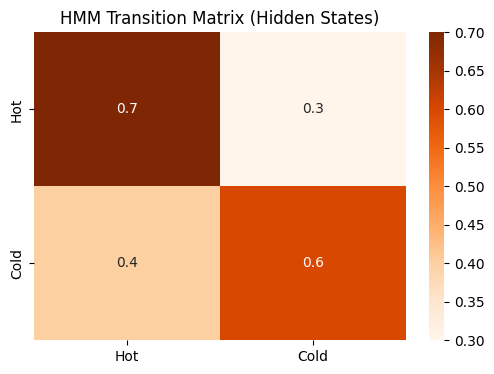

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(model.transmat_, annot=True, cmap="Oranges",
            xticklabels=hidden_states, yticklabels=hidden_states)
plt.title("HMM Transition Matrix (Hidden States)")
plt.show()

Most Likely Hidden States (Viterbi):
['Silence', 'Word1', 'Word2', 'Word2', 'Word3', 'Word3', 'Word3', 'Word3']


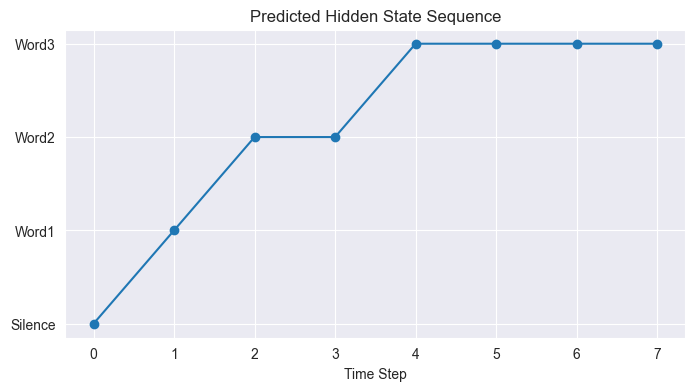

In [49]:
states = ["Silence", "Word1", "Word2", "Word3"]
n_states = len(states)
observations = ["Loud", "Soft"]
n_observations = len(observations)

start_probability = np.array([0.8, 0.1, 0.1, 0.0])
transition_probability = np.array([
    [0.7, 0.2, 0.1, 0.0],
    [0.0, 0.6, 0.4, 0.0],
    [0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 1.0]
])
emission_probability = np.array([
    [0.7, 0.3],
    [0.4, 0.6],
    [0.6, 0.4],
    [0.3, 0.7]
])

model2 = hmm.CategoricalHMM(n_components=n_states)
model2.startprob_ = start_probability
model2.transmat_ = transition_probability
model2.emissionprob_ = emission_probability

observations_sequence = np.array([0,1,0,0,1,1,0,1]).reshape(-1,1)
hidden_states_predicted = model2.predict(observations_sequence)

print("Most Likely Hidden States (Viterbi):")
print([states[i] for i in hidden_states_predicted])

sns.set_style("darkgrid")
plt.figure(figsize=(8,4))
plt.plot(hidden_states_predicted, "-o")
plt.yticks(range(n_states), states)
plt.title("Predicted Hidden State Sequence")
plt.xlabel("Time Step")
plt.show()

## CRF

In [50]:
!pip install sklearn-crfsuite
import nltk
import sklearn_crfsuite
from sklearn_crfsuite import metrics

Defaulting to user installation because normal site-packages is not writeable


In [51]:
nltk.download('treebank')
corpus = nltk.corpus.treebank.tagged_sents()
print(corpus)

[[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')], [('Mr.', 'NNP'), ('Vinken', 'NNP'), ('is', 'VBZ'), ('chairman', 'NN'), ('of', 'IN'), ('Elsevier', 'NNP'), ('N.V.', 'NNP'), (',', ','), ('the', 'DT'), ('Dutch', 'NNP'), ('publishing', 'VBG'), ('group', 'NN'), ('.', '.')], ...]


[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [52]:
def word_features(sentence, i):
    word = sentence[i][0]
    features = {
        'word': word,
        'is_first': i == 0,
        'is_last': i == len(sentence) - 1,
        'is_capitalized': word[0].upper() == word[0],
        'is_all_caps': word.upper() == word,
        'is_all_lower': word.lower() == word,
        'prefix-1': word[0],
        'prefix-2': word[:2],
        'prefix-3': word[:3],
        'suffix-1': word[-1],
        'suffix-2': word[-2:],
        'suffix-3': word[-3:],
        'prev_word': '' if i == 0 else sentence[i-1][0],
        'next_word': '' if i == len(sentence)-1 else sentence[i+1][0],
        'has_hyphen': '-' in word,
        'is_numeric': word.isdigit(),
        'capitals_inside': word[1:].lower() != word[1:]
    }
    return features

In [53]:
X = []
y = []
for sentence in corpus:
    X_sentence = []
    y_sentence = []
    for i in range(len(sentence)):
        X_sentence.append(word_features(sentence, i))
        y_sentence.append(sentence[i][1])
    X.append(X_sentence)
    y.append(y_sentence)

In [54]:
split = int(0.8 * len(X))
X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

In [55]:
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)

y_pred = crf.predict(X_test)

print(metrics.flat_accuracy_score(y_test, y_pred))

0.9632716203403363


In [56]:
import pycrfsuite

trainer = pycrfsuite.Trainer(verbose=False)
for x, y in zip(X_train, y_train):
    trainer.append(x, y)
trainer.set_params({
    'c1': 1.0,
    'c2': 1e-3,
    'max_iterations': 50,
    'feature.possible_transitions': True
})
trainer.train('pos.crfsuite')

In [57]:
tagger = pycrfsuite.Tagger()
tagger.open('pos.crfsuite')
sentence = 'Geeksforgeeks is a best platform for students.'.split()
features = [word_features(sentence, i) for i in range(len(sentence))]
tags = tagger.tag(features)
print(list(zip(sentence, tags)))

[('Geeksforgeeks', 'MD'), ('is', 'VB'), ('a', 'DT'), ('best', 'JJ'), ('platform', 'NN'), ('for', 'NN'), ('students.', 'NNS')]
